# 🌲 Day 3 Exercise: Random Forest on the House Prices Dataset

**Time required:** 90–120 minutes  
**Goal:** Build a Random Forest regressor, learn cross-validation, tune hyperparameters

Today you switch problem types: **regression** (predicting a number, not a category).

**The dataset:** California housing data. 20,000+ districts, predict median house value.

This is important: most of the data cleaning you did yesterday applies here too, but today the target is a number, not a class.ass.

### BLOCK 1: Load and Explore

In [9]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load California Housing Dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print("Shape:", df.shape)
print("\nFeature descriptions:")
for name, desc in zip(housing.feature_names, housing.feature_names):
    print(f"  {name}")
print(f"  MedHouseVal (TARGET) — median house value in $100,000")
print("\nFirst 5 rows:")
print(df.head())

Shape: (20640, 9)

Feature descriptions:
  MedInc
  HouseAge
  AveRooms
  AveBedrms
  Population
  AveOccup
  Latitude
  Longitude
  MedHouseVal (TARGET) — median house value in $100,000

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


##### Statistical Summary

In [10]:
print(df.describe().round(2))

         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00         1.15  
min       32.54    -124.35         0.15  
25%       33.93    -121.80         1.20  
50%       34.26    -118.49         1.80  
75%       37.71    -118.01         2.65  
max       41.95

##### Missing Values

In [11]:
print(f"\nMissing values: {df.isnull().sum().sum()}")


Missing values: 0


##### Distribution of target variable and correlation heatmap

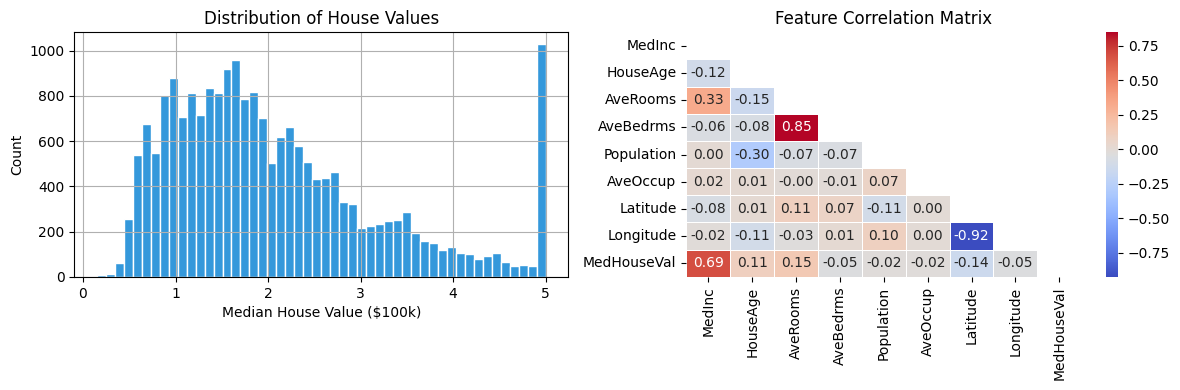


=== Correlations with target (MedHouseVal) ===
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['MedHouseVal'].hist(ax=axes[0], bins=50, color='#3498db', edgecolor='white')
axes[0].set_title('Distribution of House Values')
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_ylabel('Count')

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[1], cmap='coolwarm',
            annot=True, fmt='.2f', linewidths=0.5)
axes[1].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

print("\n=== Correlations with target (MedHouseVal) ===")
print(corr['MedHouseVal'].sort_values(ascending=False).to_string())

### BLOCK 2: Baseline Model — Linear Regression

##### Prepare data

In [15]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression Baseline
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Regresson Metrics
def evaluate_regression(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n=== {name} ===")
    print(f"  RMSE:  {rmse:.4f}  (avg error in $100k units)")
    print(f"  MAE:   {mae:.4f}  (avg absolute error)")
    print(f"  R²:    {r2:.4f}  (1.0 = perfect, 0.0 = no better than mean)")
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

lr_metrics = evaluate_regression("Linear Regression (Baseline)", y_test, lr_pred)


=== Linear Regression (Baseline) ===
  RMSE:  0.7456  (avg error in $100k units)
  MAE:   0.5332  (avg absolute error)
  R²:    0.5758  (1.0 = perfect, 0.0 = no better than mean)


### BLOCK 3: Build and Evaluate

In [18]:
# Build Random Forest
rf = RandomForestRegressor(
    n_estimators=100, # number of trees
    max_depth=None, # Trees can grow as needed
    random_state=42, 
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_metrics = evaluate_regression("Random Forest", y_test, rf_pred)

# Compare Baseline with Random Forest
print("\n=== IMPROVEMENT OVER BASELINE ===")
rmse_improvement = (lr_metrics['RMSE'] - rf_metrics['RMSE']) / lr_metrics['RMSE'] * 100
r2_improvement = rf_metrics['R2'] - lr_metrics['R2']
print(f"  RMSE reduced by:   {rmse_improvement:.1f}%")
print(f"  R² improved by:    {r2_improvement:.3f}")


=== Random Forest ===
  RMSE:  0.5053  (avg error in $100k units)
  MAE:   0.3275  (avg absolute error)
  R²:    0.8051  (1.0 = perfect, 0.0 = no better than mean)

=== IMPROVEMENT OVER BASELINE ===
  RMSE reduced by:   32.2%
  R² improved by:    0.229


##### Visualize Predictions vs Reality

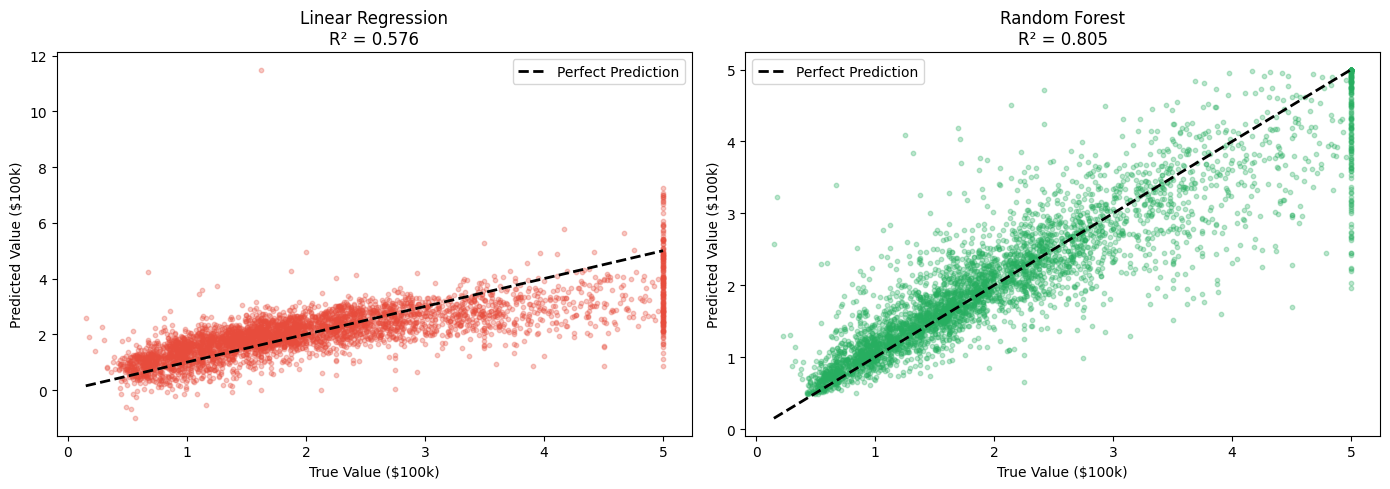

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, name, color in zip(
    axes,
    [lr_pred, rf_pred],
    ['Linear Regression', 'Random Forest'],
    ['#e74c3c', '#27ae60']
):
    ax.scatter(y_test, pred, alpha=0.3, color=color, s=10)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'k--', linewidth=2, label='Perfect Prediction')
    ax.set_xlabel('True Value ($100k)')
    ax.set_ylabel('Predicted Value ($100k)')
    ax.set_title(f'{name}\nR² = {r2_score(y_test, pred):.3f}')
    ax.legend()

plt.tight_layout()
plt.show()

# The perfect model would have all dots on the diagonal line.
# Random Forest's dots cluster much tighter to the line.

### BLOCK 4: Cross-Validation The Professional Way

In [20]:
# 5-Fold Cross Validation
# Instead of one train/test split, we test 5 times
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Linear Regression CV
lr_cv_scores = cross_val_score(
    LinearRegression(), X, y,
    cv=kf, scoring='r2', n_jobs=-1
)

# Random Forest CV (fewer trees for speed in CV)
rf_cv = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_cv_scores = cross_val_score(
    rf_cv, X, y,
    cv=kf, scoring='r2', n_jobs=-1
)

print("=" * 50)
print("CROSS-VALIDATION RESULTS (5 folds)")
print("=" * 50)
print(f"\nLinear Regression:")
print(f"  Scores:  {lr_cv_scores.round(3)}")
print(f"  Mean R²: {lr_cv_scores.mean():.3f}")
print(f"  Std:     {lr_cv_scores.std():.3f}  ← stability indicator")

print(f"\nRandom Forest:")
print(f"  Scores:  {rf_cv_scores.round(3)}")
print(f"  Mean R²: {rf_cv_scores.mean():.3f}")
print(f"  Std:     {rf_cv_scores.std():.3f}  ← stability indicator")

print("\n→ Lower std = more STABLE model across different data slices")
print("→ A model with 81% ± 1% beats one with 83% ± 8% for reliability")

CROSS-VALIDATION RESULTS (5 folds)

Linear Regression:
  Scores:  [0.576 0.614 0.609 0.621 0.588]
  Mean R²: 0.601
  Std:     0.017  ← stability indicator

Random Forest:
  Scores:  [0.804 0.811 0.803 0.819 0.801]
  Mean R²: 0.808
  Std:     0.006  ← stability indicator

→ Lower std = more STABLE model across different data slices
→ A model with 81% ± 1% beats one with 83% ± 8% for reliability


##### Visualize CV Score

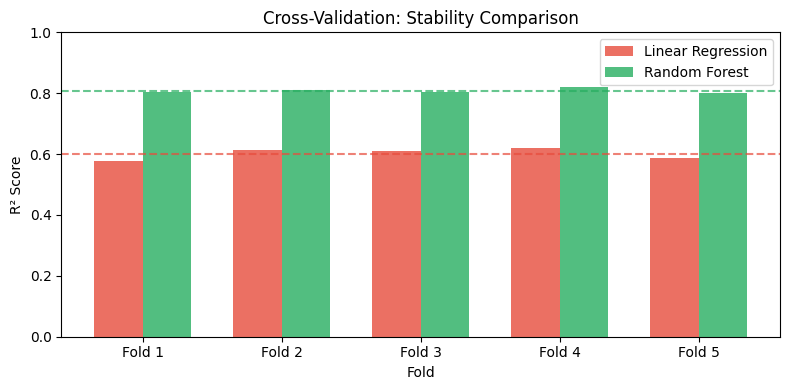

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)
width = 0.35

bars1 = ax.bar(x - width/2, lr_cv_scores, width, label='Linear Regression',
               color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, rf_cv_scores, width, label='Random Forest',
               color='#27ae60', alpha=0.8)

ax.axhline(y=lr_cv_scores.mean(), color='#e74c3c', linestyle='--', alpha=0.7)
ax.axhline(y=rf_cv_scores.mean(), color='#27ae60', linestyle='--', alpha=0.7)

ax.set_xlabel('Fold')
ax.set_ylabel('R² Score')
ax.set_title('Cross-Validation: Stability Comparison')
ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### Feature Importance + Hyperparameter Tuning

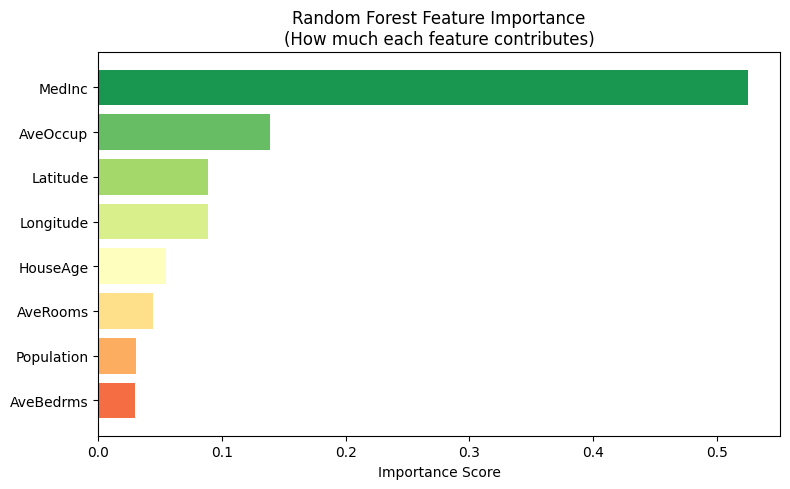

Feature importance ranking:
   Feature  Importance
    MedInc    0.524871
  AveOccup    0.138443
  Latitude    0.088936
 Longitude    0.088629
  HouseAge    0.054593
  AveRooms    0.044272
Population    0.030650
 AveBedrms    0.029606


In [22]:
# Random Forest tells you how much each feature contributed to predictions
# This is one of the most useful things in practical ML

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feature_importance)))
plt.barh(feature_importance['Feature'], feature_importance['Importance'],
         color=colors)
plt.title('Random Forest Feature Importance\n(How much each feature contributes)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Feature importance ranking:")
print(feature_importance.sort_values('Importance', ascending=False).to_string(index=False))

Testing different numbers of trees...
   10 trees → R²: 0.6271 ± 0.0477
   50 trees → R²: 0.6586 ± 0.0439
  100 trees → R²: 0.6587 ± 0.0464
  200 trees → R²: 0.6582 ± 0.0467


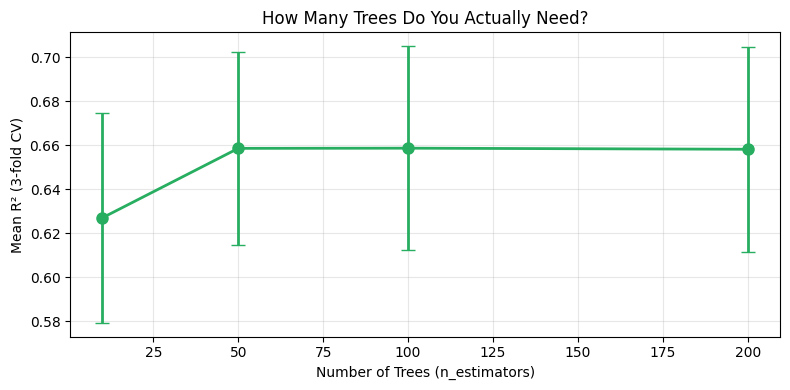


Conclusion: After a certain point, more trees = diminishing returns
There's a 'good enough' point — find it, don't over-engineer.


In [23]:
# ── Hyperparameter Tuning: Manual Exploration ────────────────
# Hyperparameters = settings you choose BEFORE training
# Parameters = values the model learns DURING training

# Key Random Forest hyperparameters:
#   n_estimators: number of trees (more = better but slower)
#   max_depth: max tree depth (lower = less overfitting)
#   min_samples_leaf: min samples at leaf (higher = smoother predictions)
results = []
n_trees_options = [10, 50, 100, 200]

print("Testing different numbers of trees...")
for n in n_trees_options:
    rf_temp = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    scores = cross_val_score(rf_temp, X, y, cv=3, scoring='r2', n_jobs=-1)
    results.append({'n_estimators': n, 'mean_r2': scores.mean(), 'std': scores.std()})
    print(f"  {n:3d} trees → R²: {scores.mean():.4f} ± {scores.std():.4f}")

results_df = pd.DataFrame(results)

plt.figure(figsize=(8, 4))
plt.errorbar(results_df['n_estimators'], results_df['mean_r2'],
             yerr=results_df['std'], fmt='o-', color='#27ae60',
             capsize=5, linewidth=2, markersize=8)
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Mean R² (3-fold CV)')
plt.title('How Many Trees Do You Actually Need?')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nConclusion: After a certain point, more trees = diminishing returns")
print("There's a 'good enough' point — find it, don't over-engineer.")

##### Depth vs Performance: Bias - Variance in Action

In [24]:
print("\nTesting max_depth: watching bias-variance tradeoff...")
print("(This is what the theory looks like in actual numbers)")

depth_results = []
depths = [1, 2, 3, 5, 8, 12, None] # None = unlimited
for depth in depths:
    rf_d = RandomForestRegressor(n_estimators=50, max_depth=depth,
                                  random_state=42, n_jobs=-1)
    rf_d.fit(X_train, y_train)
    train_r2 = r2_score(y_train, rf_d.predict(X_train))
    test_r2  = r2_score(y_test,  rf_d.predict(X_test))
    depth_label = str(depth) if depth else 'None'
    depth_results.append({'depth': depth_label, 'train_r2': train_r2, 'test_r2': test_r2})
    print(f"  depth={depth_label:4s} → train R²: {train_r2:.3f} | test R²: {test_r2:.3f}")


Testing max_depth: watching bias-variance tradeoff...
(This is what the theory looks like in actual numbers)
  depth=1    → train R²: 0.332 | test R²: 0.294
  depth=2    → train R²: 0.466 | test R²: 0.438
  depth=3    → train R²: 0.566 | test R²: 0.539
  depth=5    → train R²: 0.681 | test R²: 0.647
  depth=8    → train R²: 0.805 | test R²: 0.739
  depth=12   → train R²: 0.920 | test R²: 0.791
  depth=None → train R²: 0.972 | test R²: 0.804


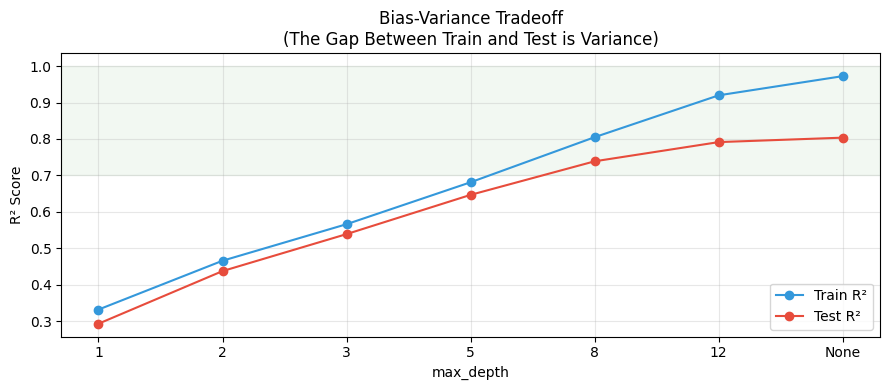

In [25]:
# The pattern you'll see:
# - depth=1: both scores low (HIGH BIAS, underfitting)
# - depth=None: train score high, test score slightly lower (some variance)
# - depth=5 or 8: sweet spot for most datasets

dr = pd.DataFrame(depth_results)
plt.figure(figsize=(9, 4))
plt.plot(range(len(dr)), dr['train_r2'], 'o-', color='#3498db', label='Train R²')
plt.plot(range(len(dr)), dr['test_r2'],  'o-', color='#e74c3c', label='Test R²')
plt.xticks(range(len(dr)), dr['depth'])
plt.xlabel('max_depth')
plt.ylabel('R² Score')
plt.title('Bias-Variance Tradeoff\n(The Gap Between Train and Test is Variance)')
plt.legend()
plt.grid(alpha=0.3)
plt.axhspan(0.7, 1.0, alpha=0.05, color='green')
plt.tight_layout()
plt.show()

### BLOCK 6: Save your Model

In [26]:
import joblib

# Save the best model
best_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)

# Save to disk
joblib.dump(best_rf, 'housing_rf_model.pkl')
print("Model saved as 'housing_rf_model.pkl'")

# Load it back (simulates what happens in production)
loaded_model = joblib.load('housing_rf_model.pkl')

# Test a prediction
sample = X_test.iloc[[0]]
pred = loaded_model.predict(sample)
actual = y_test.iloc[0]

print(f"\nLoaded model prediction:  ${pred[0]*100:.0f}k")
print(f"Actual value:             ${actual*100:.0f}k")
print(f"Error:                    ${abs(pred[0]-actual)*100:.0f}k")

Model saved as 'housing_rf_model.pkl'

Loaded model prediction:  $51k
Actual value:             $48k
Error:                    $3k
